# Using different fitting backends

## Using scipy instead of lmfit

`Moose` itself provides no fitting methods, it simply tries to give you the tools to integrate it in your own workflow.

While most examples use the [lmfit](https://lmfit.github.io/lmfit-py/) package to demonstrate fitting spectra, you can also use `scipy.optimize.curve_fit` directly.

Under the hood `lmfit` also relies on `scipy`, but their API is different for specifying fit parameters, initial values, bounds, etc.

As the example here tries to demonstrate, you can use either library to fit your data, according to your preference.

In [1]:
import Moose
import lmfit
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial

df = pd.read_csv('./N2SPS/20220302_s01_sig.cam', sep='\t', header=1, names=['Wavelength', 'I'])
df['Norm'] = (df['I']-df['I'].min())/(df['I'].max()-df['I'].min())

db = Moose.query_DB('N2CB', (320,340))
model = lmfit.Model(Moose.model_for_fit, sim_db = db, normalize=True)
params = lmfit.create_params(**Moose.default_params)
params['T_vib'].max = 15000 # adjust maximum 


In [2]:
result_lmfit = model.fit(df['Norm'].to_numpy(), x = df['Wavelength'].to_numpy(), params=params)
result_scipy = curve_fit(
    partial(Moose.model_for_fit, sim_db=db), 
    xdata=df['Wavelength'].to_numpy(), 
    ydata=df['Norm'].to_numpy(), 
    p0=[v['value'] for v in Moose.default_params.values() if v.get('vary',True)], 
    bounds = (
        [params[p].min for p in params if params[p].vary],
        [params[p].max for p in params if params[p].vary]
    )
) 

Text(0.5, 0, '$\\lambda$ (nm)')

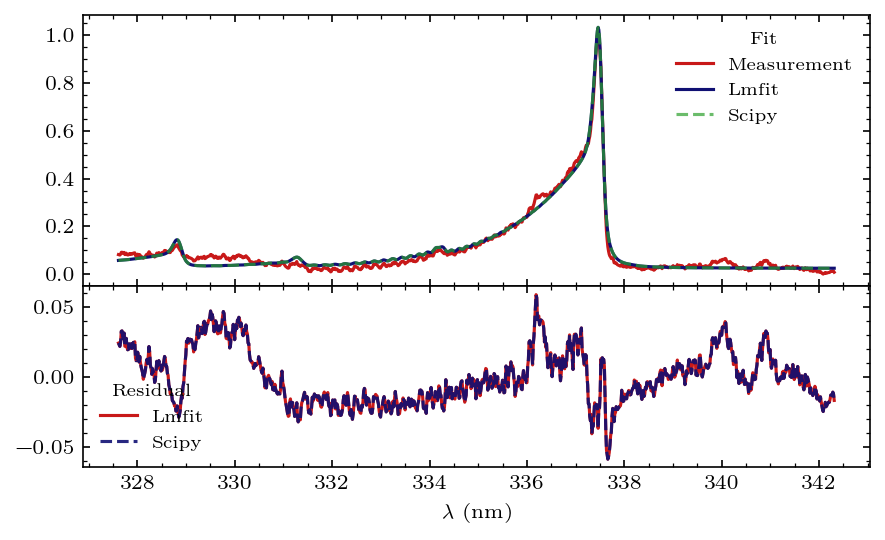

In [3]:
fig, ax = plt.subplots(2,1, figsize=(6,3.7),sharex=True, tight_layout=True, gridspec_kw={'hspace':0, 'height_ratios':[3,2]})
df.plot(x='Wavelength', y='Norm', ax=ax[0], label='Measurement')
ax[0].plot(df['Wavelength'], result_lmfit.best_fit, label='Lmfit')
ax[0].plot(df['Wavelength'], Moose.model_for_fit(df['Wavelength'].values, *result_scipy[0], sim_db=db), label='Scipy', ls='--', alpha=0.7)
ax[0].legend(title='Fit', fontsize=9, title_fontsize=9)

# ax[1].plot(df['Wavelength'], result_lmfit.residual - (Moose.model_for_fit(df['Wavelength'].values, *result_scipy[0], sim_db=db)-df['Norm']), label='Difference')
ax[1].plot(df['Wavelength'], result_lmfit.residual, label='Lmfit')
ax[1].plot(df['Wavelength'], df['Norm'] - Moose.model_for_fit(df['Wavelength'].values, *result_scipy[0], sim_db=db), label='Scipy', alpha=0.9, ls='--')
ax[1].legend(title='Residual', fontsize=9, title_fontsize=9)
ax[1].set_xlabel(r'$\lambda$ (nm)')

In [4]:
%timeit -r 10 -n 10 result_lmfit = model.fit(df['Norm'].values, x = df['Wavelength'].values, params=params)
%timeit -r 10 -n 10 result_scipy = curve_fit(partial(Moose.model_for_fit, sim_db=db), xdata=df['Wavelength'].values, ydata=df['Norm'].values, p0=[params[p].value for p in params if params[p].vary is True],bounds = ([params[p].min for p in params if params[p].vary is True],[params[p].max for p in params if params[p].vary is True]))

124 ms ± 15.1 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)
112 ms ± 6.58 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


## Using iminuit

It is also possible to use an altogether different fitting backend, such as `iminuit` instead of `scipy`. 

Iminuit has different requirements for the model function, which it enforces by inspecting the function signature.

As a result, all arguments will be assumed to be (and treated as) floats, which is not the case for `Moose.model_for_fit`.

Freezing arguments with `functools.partial` does not work in this instance, since iminuit will treat the frozen arguments as missing and raise an error.

To still define a model function that meets the expectation of iminuit, you can wrap your function with `Moose.iminuit.as_minuit_objective` instead.

Any keyword argument that you pass to this wrapper will be frozen and hidden from iminuit, meaning you can provide e.g. line-by-line databases and boolean flags again.

In [5]:
from iminuit import Minuit
from iminuit.cost import LeastSquares

from Moose.iminuit import as_minuit_objective

# Define the objective function
objective = as_minuit_objective(Moose.model_for_fit,sim_db = db, normalize=True)

In [6]:
# Setup iminuit with model and apply parameter bounds/fixing
ls = LeastSquares(x = df.iloc[:,0], y = df.iloc[:,2], yerror = df.iloc[:,2].nsmallest(100).std(), model = objective)
m = Minuit(ls, **{k:v['value'] for k,v in Moose.default_params.items()}) # provide all default values from Moose.default_params as initial estimates

# Apply bounds to parameters that need to be varied, while fixing others, using Moose.default_params
for name in params:
    par = params[name]
    if par.vary:
        m.limits[name] = (par.min, par.max)
    else:
        m.fixto(name,par.value)

In the above code we have set up the minimizer to use a least-squares cost function, with bounds applied to some parameters, while others have been fixed.

A very similar approach to how `lmfit` works.

Now we run the minimizer using the `migrad` method, which will fit the data and show nicely formatted output (in a notebook).

Note that the plotted graph is subsampled by default and will thus not actually represent the actual fit perfectly.

This behaviour can be changed, but is left as is here.

In [7]:
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.434e+04 (χ²/ndof = 14.1) │              Nfcn = 384              │
│ EDM = 3.49e-07 (Goal: 0.0002)    │            time = 1.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name       │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ sigma      │  0.0376   │  0.0010   │            │            │ 0.0001  │   0.3   │       │
│ 1 │ gamma      │  49.5e-3  │  0.8e-3   │            │            │ 0.0001  │   0.3   │       │
│ 2 │ mu         │ 274.70e-3 │  0.27e-3  │            │            │   -2    │    2    │       │
│ 3 │ T_rot      │  1.182e3  │  0.004e3  │            │            │   250   │  10000  │       │
│ 4 │ T_vib      │  10.96e3  │  0.14e3   │            │            │   250   │  15000  │       │
│ 5 │ A          │  1.0088   │  0.0019   │            │            │   0.2   │    2    │       │
│ 6 │ b          │ 24.57e-3  │  0.24e-3  │            │            │  -0.05  │  0.05   │       │
│ 7 │ resolution │    100    │     1     │            │            │         │         │  yes  │
│ 8 │ wl_pad     │   10.0    │    0.1    │            │            │         │         │  yes  │
└───┴────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│            │        sigma        gamma           mu        T_rot        T_vib            A            b   resolution       wl_pad │
├────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│      sigma │     1.03e-06      -0.7e-6      0.01e-6    1.2125e-3  -16.7897e-3      -0.6e-6      0.04e-6         0e-6         0e-6 │
│      gamma │      -0.7e-6      5.7e-07     -0.03e-6   -1.4214e-3   15.3708e-3           -0     -0.03e-6            0            0 │
│         mu │      0.01e-6     -0.03e-6     7.17e-08    378.40e-6    876.36e-6     -0.03e-6     -0.01e-6            0            0 │
│      T_rot │    1.2125e-3   -1.4214e-3    378.40e-6         17.6           45    -1.233e-3   -352.11e-6            0            0 │
│      T_vib │  -16.7897e-3   15.3708e-3    876.36e-6           45     1.93e+04   -11.223e-3 -14.74764e-3            0            0 │
│          A │      -0.6e-6           -0     -0.03e-6    -1.233e-3   -11.223e-3     3.65e-06     -0.01e-6         0e-6         0e-6 │
│          b │      0.04e-6     -0.03e-6     -0.01e-6   -352.11e-6 -14.74764e-3     -0.01e-6     5.69e-08            0            0 │
│ resolution │         0e-6            0            0            0            0         0e-6            0            0            0 │
│     wl_pad │         0e-6            0            0            0            0         0e-6            0            0            0 │
└────────────┴──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

All the above approaches have used least-squares fitting.

Let's see how their results compare to each other.

In [8]:
print(f"{'Param':12s} {'scipy':9s} {'lmfit':9s} {'iminuit':9s}")
for i, param_name in enumerate(m.parameters):
    if not m.params[param_name].is_fixed:
        print(f"{param_name:>12s} {result_scipy[0][i]:9.3g} {result_lmfit.params[param_name].value:9.3g} {m.params[param_name].value:9.3g}")

Param        scipy     lmfit     iminuit  
       sigma    0.0376    0.0376    0.0376
       gamma    0.0495    0.0495    0.0495
          mu     0.275     0.275     0.275
       T_rot  1.18e+03  1.18e+03  1.18e+03
       T_vib   1.1e+04   1.1e+04   1.1e+04
           A      1.01      1.01      1.01
           b    0.0246    0.0246    0.0246


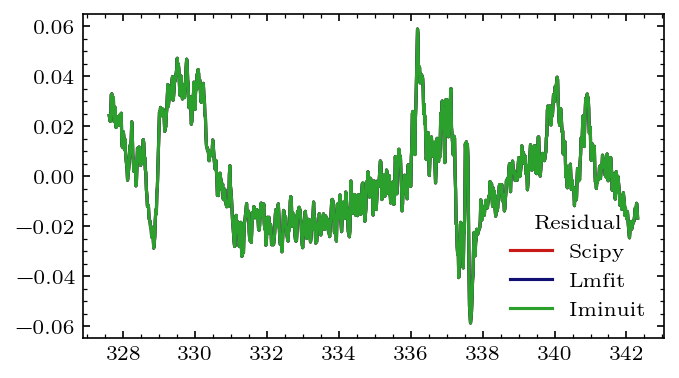

In [9]:
x = df.iloc[:,0].to_numpy()
y = df.iloc[:,2].to_numpy()
plt.plot(x, y-Moose.model_for_fit(x,*result_scipy[0],sim_db=db, normalize=True), label="Scipy")
plt.plot(x, y-Moose.model_for_fit(x,**result_lmfit.params.valuesdict(),sim_db=db, normalize=True), label="Lmfit")
plt.plot(x, y-Moose.model_for_fit(x,**m.values.to_dict(),sim_db=db, normalize=True), label="Iminuit")

plt.legend(title="Residual")